# Solución del Lab 04: Regresión lineal y gradiente descendente

En este notebook se resuelven los puntos del laboratorio con el mismo estilo práctico: explicación corta + implementación + visualización.

Objetivos principales:
- Construir y analizar la función de costo de una regresión lineal.
- Encontrar parámetros óptimos por búsqueda y por gradiente descendente.
- Interpretar la geometría del costo y su sensibilidad a ruido/outliers.
- Comparar con `LinearRegression` de `sklearn`.

Primeras filas del DataFrame:


,X,y
0,0.00000,5.000000
1,0.10101,5.202020
2,0.20202,5.404040
3,0.30303,5.606061
4,0.40404,5.808081


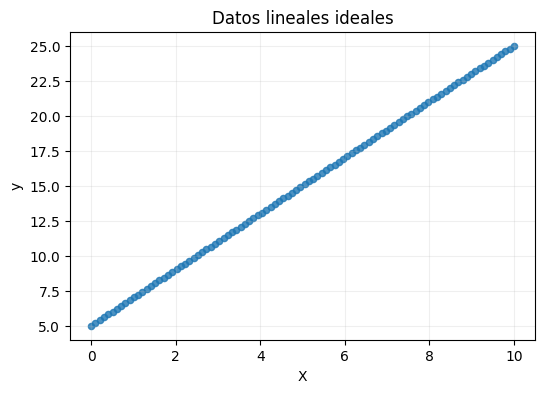

Costo en parámetros reales: 0.000000


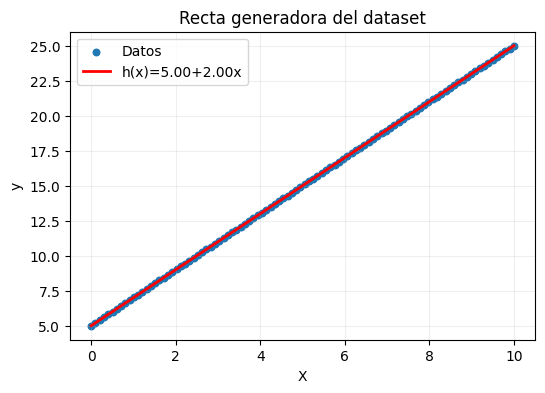

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# -----------------------------
# Punto 1: dataset lineal simple
# -----------------------------
theta0_real = 5.0
theta1_real = 2.0
X = np.linspace(0, 10, 100)
y = theta0_real + theta1_real * X

df_lineal = pd.DataFrame({"X": X, "y": y})
print("Primeras filas del DataFrame:")
display(df_lineal.head())

plt.figure(figsize=(6, 4))
plt.scatter(df_lineal["X"], df_lineal["y"], s=20, alpha=0.8)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Datos lineales ideales")
plt.grid(alpha=0.2)
plt.show()


# -------------------------------------
# Punto 2: hipótesis y función de costo
# -------------------------------------
def hipotesis_lineal(theta0, theta1, X):
    return theta0 + theta1 * X


def costo_mse(theta0, theta1, X, y):
    m = len(y)
    pred = hipotesis_lineal(theta0, theta1, X)
    return (1 / (2 * m)) * np.sum((pred - y) ** 2)


def graficar_ajuste(X, y, theta0, theta1, titulo="Ajuste lineal"):
    y_pred = hipotesis_lineal(theta0, theta1, X)
    plt.figure(figsize=(6, 4))
    plt.scatter(X, y, s=22, label="Datos")
    plt.plot(X, y_pred, "r", linewidth=2, label=f"h(x)={theta0:.2f}+{theta1:.2f}x")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title(titulo)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

print(f"Costo en parámetros reales: {costo_mse(theta0_real, theta1_real, X, y):.6f}")
graficar_ajuste(X, y, theta0_real, theta1_real, "Recta generadora del dataset")

Con theta0=0, el mejor theta1 es: 2.7469
Costo mínimo asociado: 3.1721


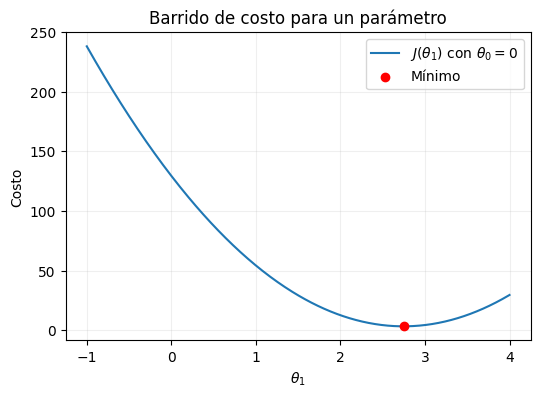

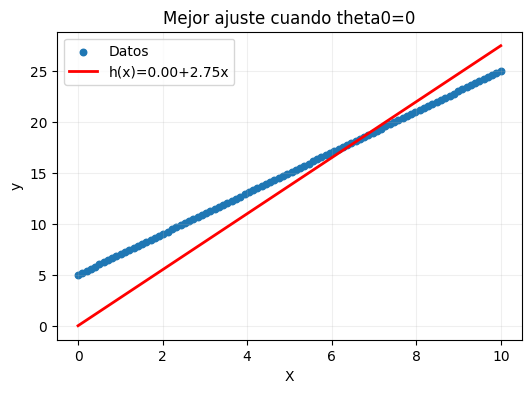

In [32]:
# --------------------------------------------------------------
# Punto 3: fijamos theta0=0 y estudiamos J(theta1)
# --------------------------------------------------------------
theta0_fijo = 0.0
theta1_grid = np.linspace(-1, 4, 400)

costos_theta1 = np.array([costo_mse(theta0_fijo, t1, X, y) for t1 in theta1_grid])
idx_min = np.argmin(costos_theta1)
theta1_opt_fijo = theta1_grid[idx_min]
costo_min_fijo = costos_theta1[idx_min]

print(f"Con theta0=0, el mejor theta1 es: {theta1_opt_fijo:.4f}")
print(f"Costo mínimo asociado: {costo_min_fijo:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(theta1_grid, costos_theta1, label=r"$J(\theta_1)$ con $\theta_0=0$")
plt.scatter(theta1_opt_fijo, costo_min_fijo, color="red", zorder=3, label="Mínimo")
plt.xlabel(r"$\theta_1$")
plt.ylabel("Costo")
plt.title("Barrido de costo para un parámetro")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

graficar_ajuste(X, y, theta0_fijo, theta1_opt_fijo, "Mejor ajuste cuando theta0=0")

Mínimo global aproximado en malla: theta0=4.9580, theta1=2.0168
Costo mínimo en malla: 0.00208342


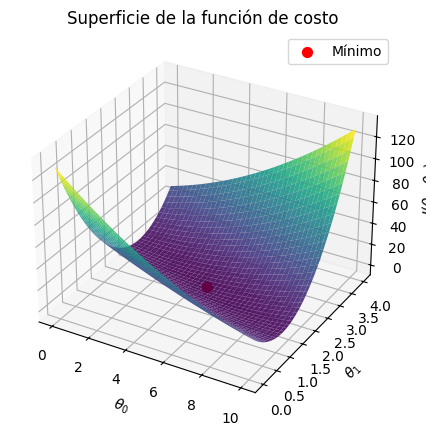

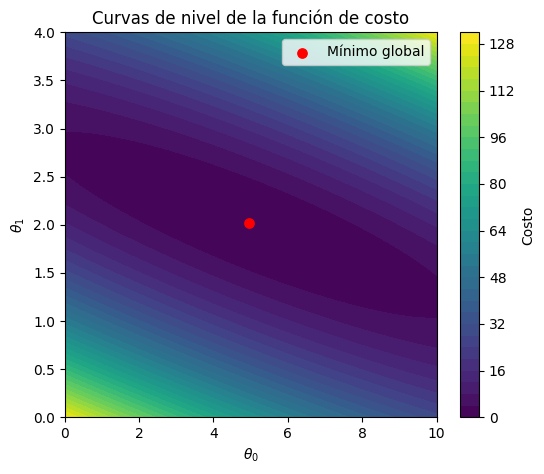

Interpretación geométrica: la superficie es convexa (tipo paraboloide),
por lo tanto existe un único mínimo global para este problema lineal ideal.


In [33]:
# -----------------------------------------------------------------
# Puntos 4 y 5: ahora varían theta0 y theta1 (superficie y contorno)
# -----------------------------------------------------------------
theta0_vals = np.linspace(0, 10, 120)
theta1_vals = np.linspace(0, 4, 120)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

# Cálculo vectorizado del costo en toda la malla
Y_pred_malla = T0[..., None] + T1[..., None] * X[None, None, :]
J_malla = (1 / (2 * len(y))) * np.sum((Y_pred_malla - y[None, None, :]) ** 2, axis=2)

# Mínimo global de la malla
idx_global = np.unravel_index(np.argmin(J_malla), J_malla.shape)
t0_opt = T0[idx_global]
t1_opt = T1[idx_global]
j_opt = J_malla[idx_global]

print(f"Mínimo global aproximado en malla: theta0={t0_opt:.4f}, theta1={t1_opt:.4f}")
print(f"Costo mínimo en malla: {j_opt:.8f}")

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(T0, T1, J_malla, cmap="viridis", alpha=0.9)
ax.scatter(t0_opt, t1_opt, j_opt, color="red", s=50, label="Mínimo")
ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_zlabel(r"$J(\theta_0,\theta_1)$")
ax.set_title("Superficie de la función de costo")
plt.legend()
plt.show()

plt.figure(figsize=(6, 5))
cont = plt.contourf(T0, T1, J_malla, levels=40, cmap="viridis")
plt.colorbar(cont, label="Costo")
plt.scatter(t0_opt, t1_opt, c="red", s=45, label="Mínimo global")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$")
plt.title("Curvas de nivel de la función de costo")
plt.legend()
plt.show()

print("Interpretación geométrica: la superficie es convexa (tipo paraboloide),")
print("por lo tanto existe un único mínimo global para este problema lineal ideal.")

In [34]:
# Sección de análisis adicional (puntos 6 a 9)
print("Análisis adicional: ruido, outliers, no linealidad e interpretación teórica.")

Análisis adicional: ruido, outliers, no linealidad e interpretación teórica.


Con ruido: theta0~4.790, theta1~2.017


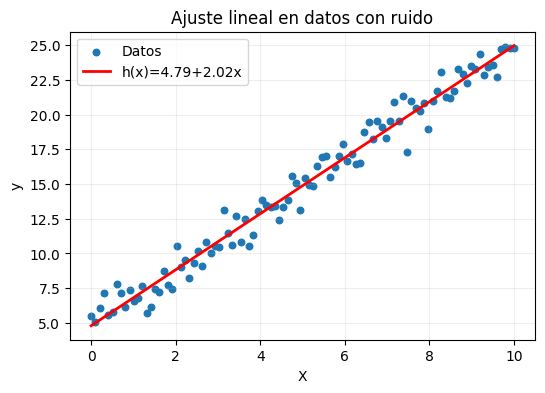

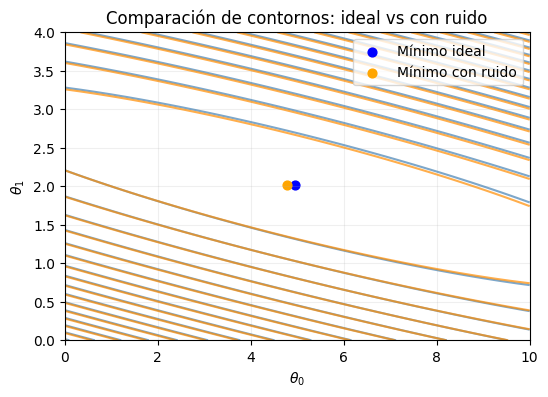

El ruido desplaza ligeramente el mínimo y ensancha las curvas de nivel.
Con outlier: theta0~4.538, theta1~2.118


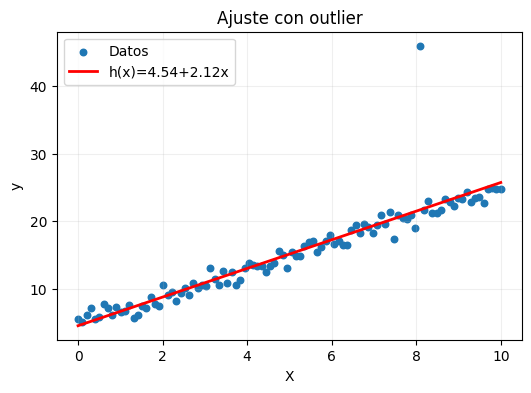

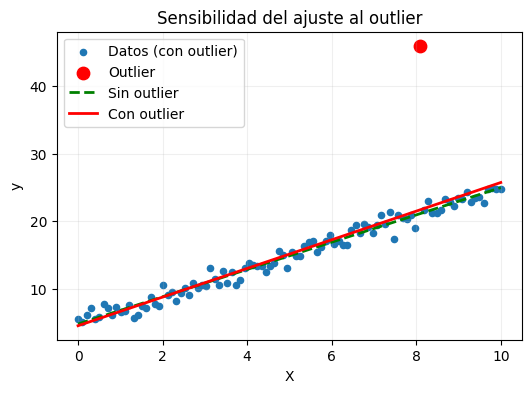

La pérdida cuadrática penaliza mucho errores grandes; por eso un solo outlier
puede mover de forma importante la solución óptima.


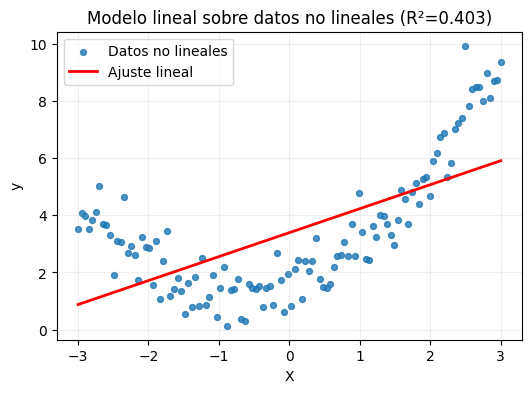

Minimizar J garantiza el mejor ajuste DENTRO de la familia elegida (rectas),
pero no garantiza que el modelo sea adecuado para datos no lineales.


In [35]:
# -----------------------------
# Punto 6: datos con ruido
# -----------------------------
ruido = np.random.normal(0, 1.0, size=len(X))
y_ruido = theta0_real + theta1_real * X + ruido

# Reutilizamos la malla para estimar el mínimo en el caso ruidoso
Y_pred_ruido = T0[..., None] + T1[..., None] * X[None, None, :]
J_malla_ruido = (1 / (2 * len(y_ruido))) * np.sum((Y_pred_ruido - y_ruido[None, None, :]) ** 2, axis=2)
idx_ruido = np.unravel_index(np.argmin(J_malla_ruido), J_malla_ruido.shape)
t0_ruido, t1_ruido = T0[idx_ruido], T1[idx_ruido]

print(f"Con ruido: theta0~{t0_ruido:.3f}, theta1~{t1_ruido:.3f}")

graficar_ajuste(X, y_ruido, t0_ruido, t1_ruido, "Ajuste lineal en datos con ruido")

plt.figure(figsize=(6, 4))
plt.contour(T0, T1, J_malla, levels=20, colors="steelblue", alpha=0.7)
plt.contour(T0, T1, J_malla_ruido, levels=20, colors="darkorange", alpha=0.7)
plt.scatter(t0_opt, t1_opt, c="blue", s=40, label="Mínimo ideal")
plt.scatter(t0_ruido, t1_ruido, c="orange", s=40, label="Mínimo con ruido")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$")
plt.title("Comparación de contornos: ideal vs con ruido")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("El ruido desplaza ligeramente el mínimo y ensancha las curvas de nivel.")


# -----------------------------------------
# Punto 7: efecto de un valor atípico
# -----------------------------------------
y_outlier = y_ruido.copy()
y_outlier[80] += 25  # introducimos un outlier fuerte

Y_pred_outlier = T0[..., None] + T1[..., None] * X[None, None, :]
J_malla_outlier = (1 / (2 * len(y_outlier))) * np.sum((Y_pred_outlier - y_outlier[None, None, :]) ** 2, axis=2)
idx_out = np.unravel_index(np.argmin(J_malla_outlier), J_malla_outlier.shape)
t0_out, t1_out = T0[idx_out], T1[idx_out]

print(f"Con outlier: theta0~{t0_out:.3f}, theta1~{t1_out:.3f}")

graficar_ajuste(X, y_outlier, t0_out, t1_out, "Ajuste con outlier")

plt.figure(figsize=(6, 4))
plt.scatter(X, y_outlier, s=20, label="Datos (con outlier)")
plt.scatter(X[80], y_outlier[80], c="red", s=80, label="Outlier")
plt.plot(X, hipotesis_lineal(t0_ruido, t1_ruido, X), "g--", lw=2, label="Sin outlier")
plt.plot(X, hipotesis_lineal(t0_out, t1_out, X), "r", lw=2, label="Con outlier")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Sensibilidad del ajuste al outlier")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("La pérdida cuadrática penaliza mucho errores grandes; por eso un solo outlier")
print("puede mover de forma importante la solución óptima.")


# ----------------------------------------------------
# Punto 8: datos no lineales y ajuste lineal forzado
# ----------------------------------------------------
X_nl = np.linspace(-3, 3, 120)
y_nl = 0.6 * X_nl**2 + 0.8 * X_nl + 1.5 + np.random.normal(0, 0.7, len(X_nl))

# Ajuste lineal por fórmula cerrada (mínimos cuadrados)
X_design = np.c_[np.ones(len(X_nl)), X_nl]
theta_ls = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_nl

t0_nl, t1_nl = theta_ls

yhat_nl = hipotesis_lineal(t0_nl, t1_nl, X_nl)
ss_res = np.sum((y_nl - yhat_nl) ** 2)
ss_tot = np.sum((y_nl - np.mean(y_nl)) ** 2)
r2_lineal_nl = 1 - ss_res / ss_tot

plt.figure(figsize=(6, 4))
plt.scatter(X_nl, y_nl, s=18, alpha=0.8, label="Datos no lineales")
plt.plot(X_nl, yhat_nl, "r", lw=2, label="Ajuste lineal")
plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Modelo lineal sobre datos no lineales (R²={r2_lineal_nl:.3f})")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Minimizar J garantiza el mejor ajuste DENTRO de la familia elegida (rectas),")
print("pero no garantiza que el modelo sea adecuado para datos no lineales.")

## Punto 9: expresión teórica del costo

Caso con un parámetro (fijando $\theta_0$):

$$
J(\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(\theta_0+\theta_1x^{(i)}-y^{(i)}\right)^2
$$

Este costo es una parábola en $\theta_1$, por lo que su mínimo es único.

Caso con dos parámetros:

$$
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(\theta_0+\theta_1x^{(i)}-y^{(i)}\right)^2
$$

La superficie es un paraboloide convexo en $(\theta_0,\theta_1)$, con mínimo global único (sin regularización adicional).

## Punto 10: gradiente descendente en 1D

Se implementa gradiente descendente para minimizar:

$$
f(x)=(x-4)^2
$$

con criterio de parada por error $\epsilon=10^{-4}$ y tres tasas de aprendizaje.

alpha=0.05 -> mínimo aprox=3.980592, iteraciones=61
alpha=0.2  -> mínimo aprox=3.994358, iteraciones=15
alpha=0.8  -> mínimo aprox=4.005642, iteraciones=15


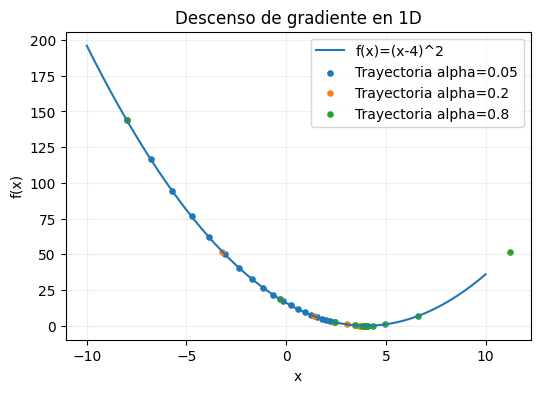

In [36]:
def gradiente_descendente_1d(df, ddf, x0, alpha=0.1, epsilon=1e-4, max_iter=10000):
    x = float(x0)
    historial = [x]

    for i in range(max_iter):
        grad = ddf(x)
        x_new = x - alpha * grad
        historial.append(x_new)

        if abs(df(x_new) - df(x)) < epsilon:
            return x_new, i + 1, np.array(historial)

        x = x_new

    return x, max_iter, np.array(historial)


def f(x):
    return (x - 4) ** 2


def df(x):
    return 2 * (x - 4)


x0 = -8
alphas = [0.05, 0.2, 0.8]

for alpha in alphas:
    x_min, n_iter, hist = gradiente_descendente_1d(f, df, x0=x0, alpha=alpha, epsilon=1e-4)
    print(f"alpha={alpha:<4} -> mínimo aprox={x_min:.6f}, iteraciones={n_iter}")

x_plot = np.linspace(-10, 10, 400)
plt.figure(figsize=(6, 4))
plt.plot(x_plot, f(x_plot), label="f(x)=(x-4)^2")
for alpha in alphas:
    x_min, n_iter, hist = gradiente_descendente_1d(f, df, x0=x0, alpha=alpha, epsilon=1e-4)
    plt.scatter(hist[:20], f(hist[:20]), s=14, label=f"Trayectoria alpha={alpha}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descenso de gradiente en 1D")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Punto 11: descenso de gradiente en 2D

Función a minimizar:

$$
F(x,y)=\sin\left(\frac{1}{2}x^2-\frac{1}{4}y^2+3\right)\cos(2x+1-e^y)
$$

Se muestra la superficie, el contorno y la trayectoria del descenso.

Mínimo local encontrado en: x=2.20187, y=1.68710
Valor de F en el mínimo: -1.000000
Iteraciones: 92


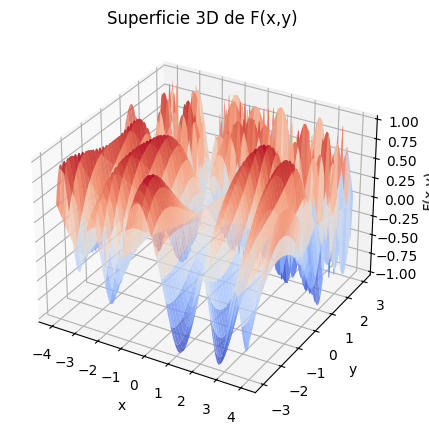

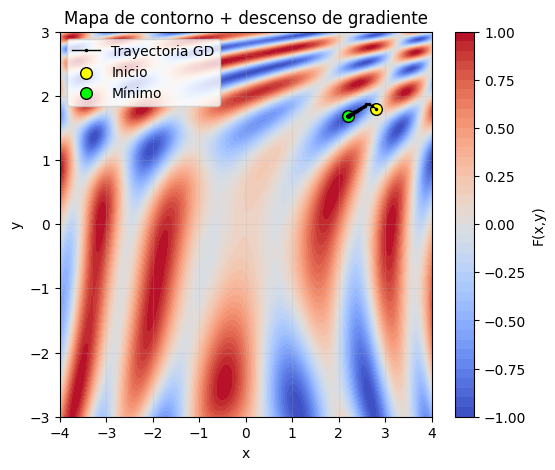

In [37]:
def F(x, y):
    return np.sin(0.5 * x**2 - 0.25 * y**2 + 3) * np.cos(2 * x + 1 - np.exp(y))


def grad_F_num(x, y, h=1e-5):
    dFx = (F(x + h, y) - F(x - h, y)) / (2 * h)
    dFy = (F(x, y + h) - F(x, y - h)) / (2 * h)
    return np.array([dFx, dFy])


def gd_2d(x0, y0, alpha=0.03, epsilon=1e-5, max_iter=5000):
    p = np.array([x0, y0], dtype=float)
    trayectoria = [p.copy()]

    for i in range(max_iter):
        grad = grad_F_num(p[0], p[1])
        p_new = p - alpha * grad
        trayectoria.append(p_new.copy())

        if np.linalg.norm(p_new - p) < epsilon:
            return p_new, i + 1, np.array(trayectoria)

        p = p_new

    return p, max_iter, np.array(trayectoria)

# Malla para visualización
xv = np.linspace(-4, 4, 220)
yv = np.linspace(-3, 3, 220)
XX, YY = np.meshgrid(xv, yv)
ZZ = F(XX, YY)

# Ejecutamos descenso
a = 0.03
p_min, n_it, path = gd_2d(x0=2.8, y0=1.8, alpha=a, epsilon=1e-5, max_iter=5000)
print(f"Mínimo local encontrado en: x={p_min[0]:.5f}, y={p_min[1]:.5f}")
print(f"Valor de F en el mínimo: {F(p_min[0], p_min[1]):.6f}")
print(f"Iteraciones: {n_it}")

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XX, YY, ZZ, cmap='coolwarm', alpha=0.8, linewidth=0)
ax.set_title('Superficie 3D de F(x,y)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('F(x,y)')
plt.show()

plt.figure(figsize=(6, 5))
cp = plt.contourf(XX, YY, ZZ, levels=40, cmap='coolwarm')
plt.colorbar(cp, label='F(x,y)')
plt.plot(path[:, 0], path[:, 1], 'k.-', markersize=3, linewidth=1, label='Trayectoria GD')
plt.scatter(path[0, 0], path[0, 1], c='yellow', s=70, edgecolor='k', label='Inicio')
plt.scatter(p_min[0], p_min[1], c='lime', s=70, edgecolor='k', label='Mínimo')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mapa de contorno + descenso de gradiente')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Punto 12: regresión lineal por gradiente descendente y comparación con sklearn

Datos del enunciado:

```python
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)
```

Se ajusta el modelo por gradiente descendente y luego se compara con `LinearRegression`.

GD -> theta0=0.208582, theta1=0.201221, costo final=0.00001662
sklearn -> theta0=0.208582, theta1=0.201221


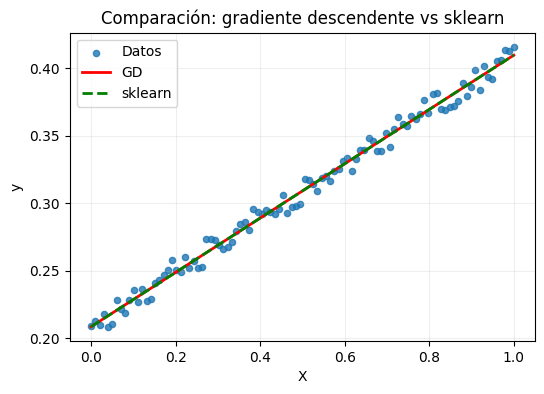

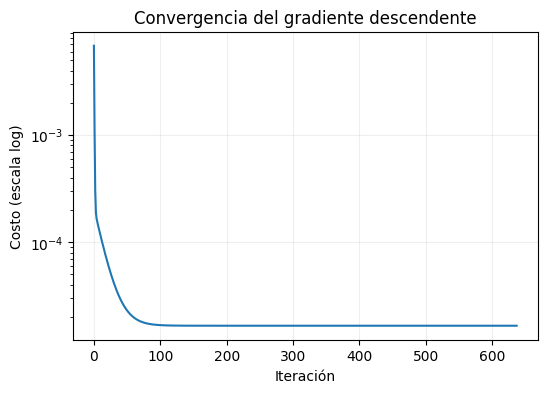

In [38]:
# Dataset del enunciado
X_lab = np.linspace(0, 1, 100)
y_lab = 0.2 + 0.2 * X_lab + 0.02 * np.random.random(100)


def gradiente_descendente_lineal(X, y, alpha=0.1, n_iter=5000, tol=1e-10):
    m = len(y)
    theta0, theta1 = 0.0, 0.0
    historial = []

    for _ in range(n_iter):
        y_pred = theta0 + theta1 * X
        error = y_pred - y

        grad0 = (1 / m) * np.sum(error)
        grad1 = (1 / m) * np.sum(error * X)

        new_theta0 = theta0 - alpha * grad0
        new_theta1 = theta1 - alpha * grad1

        historial.append(costo_mse(new_theta0, new_theta1, X, y))

        if np.linalg.norm([new_theta0 - theta0, new_theta1 - theta1]) < tol:
            theta0, theta1 = new_theta0, new_theta1
            break

        theta0, theta1 = new_theta0, new_theta1

    return theta0, theta1, np.array(historial)


# Ajuste por gradiente descendente
t0_gd, t1_gd, hist_lab = gradiente_descendente_lineal(X_lab, y_lab, alpha=0.5, n_iter=20000, tol=1e-12)
print(f"GD -> theta0={t0_gd:.6f}, theta1={t1_gd:.6f}, costo final={hist_lab[-1]:.8f}")

# Ajuste con sklearn
model = LinearRegression()
model.fit(X_lab.reshape(-1, 1), y_lab)
t0_sk = model.intercept_
t1_sk = model.coef_[0]

print(f"sklearn -> theta0={t0_sk:.6f}, theta1={t1_sk:.6f}")

plt.figure(figsize=(6, 4))
plt.scatter(X_lab, y_lab, s=20, alpha=0.8, label="Datos")
plt.plot(X_lab, hipotesis_lineal(t0_gd, t1_gd, X_lab), 'r', lw=2, label='GD')
plt.plot(X_lab, hipotesis_lineal(t0_sk, t1_sk, X_lab), 'g--', lw=2, label='sklearn')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparación: gradiente descendente vs sklearn')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(hist_lab)
plt.yscale('log')
plt.xlabel('Iteración')
plt.ylabel('Costo (escala log)')
plt.title('Convergencia del gradiente descendente')
plt.grid(alpha=0.2)
plt.show()

## Punto 12 (30%): versión tipo librería

A continuación se deja una implementación estilo librería (funciones documentadas y una función principal `fit_linear_gd`).

Esto permite mover fácilmente el código a un paquete de Python.

In [39]:
def linear_hypothesis(X, theta0, theta1):
    """Calcula h(x) = theta0 + theta1*x para un arreglo X."""
    return theta0 + theta1 * X


def linear_cost(X, y, theta0, theta1):
    """Costo cuadrático medio escalado: J = (1/(2m))*sum((h-y)^2)."""
    m = len(y)
    return (1 / (2 * m)) * np.sum((linear_hypothesis(X, theta0, theta1) - y) ** 2)


def run_gradient_descent(X, y, alpha=0.1, n_iter=10000, tol=1e-12):
    """Ejecuta descenso de gradiente para theta0 y theta1."""
    m = len(y)
    theta0, theta1 = 0.0, 0.0
    history = []

    for _ in range(n_iter):
        pred = linear_hypothesis(X, theta0, theta1)
        err = pred - y

        g0 = np.sum(err) / m
        g1 = np.sum(err * X) / m

        nt0 = theta0 - alpha * g0
        nt1 = theta1 - alpha * g1

        history.append(linear_cost(X, y, nt0, nt1))

        if np.linalg.norm([nt0 - theta0, nt1 - theta1]) < tol:
            theta0, theta1 = nt0, nt1
            break

        theta0, theta1 = nt0, nt1

    return theta0, theta1, np.array(history)


def fit_linear_gd(X, y, alpha=0.1, n_iter=10000, tol=1e-12):
    """Función principal para ajustar regresión lineal con GD."""
    theta0, theta1, history = run_gradient_descent(X, y, alpha=alpha, n_iter=n_iter, tol=tol)
    return {
        "theta0": theta0,
        "theta1": theta1,
        "history": history,
        "predict": lambda x_new: linear_hypothesis(np.asarray(x_new), theta0, theta1),
    }

# Ejemplo de uso tipo librería
model_lib = fit_linear_gd(X_lab, y_lab, alpha=0.5, n_iter=20000)
print("Parámetros con API tipo librería:")
print(f"theta0={model_lib['theta0']:.6f}, theta1={model_lib['theta1']:.6f}")
print(f"Predicción para x=0.5 -> {model_lib['predict']([0.5])[0]:.6f}")

Parámetros con API tipo librería:
theta0=0.208582, theta1=0.201221
Predicción para x=0.5 -> 0.309192
